# Sentiment Analysis for META (Meta Platforms Inc.)

This notebook performs sentiment analysis specifically on META-related news headlines.

## Focus:
- Meta/Facebook stock sentiment analysis
- Social media sector sentiment
- Metaverse and digital advertising sentiment indicators

## Tools:
- TextBlob for primary sentiment analysis
- NLTK VADER for comparison

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK VADER data (only needed once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load META-specific data
print("Loading META data...")

# Load raw analyst ratings data
raw_data = pd.read_csv('../../../data/newsData/raw_analyst_ratings.csv')
print(f"Total dataset shape: {raw_data.shape}")

# Filter for META only (also check for FB as it might be in older data)
meta_data = raw_data[(raw_data['stock'] == 'META') | (raw_data['stock'] == 'FB')].copy()
# Standardize to META
meta_data['stock'] = 'META'
print(f"META headlines: {len(meta_data)}")

# Load aligned data
aligned_data = pd.read_csv('../../../data/aligned_data/news_mapped_to_trading_days.csv')
meta_aligned = aligned_data[(aligned_data['stock'] == 'META') | (aligned_data['stock'] == 'FB')].copy()
meta_aligned['stock'] = 'META'
print(f"META aligned data: {len(meta_aligned)}")

# Display sample META headlines
print("\nSample META headlines:")
for i, headline in enumerate(meta_data['headline'].head(5).tolist()):
    print(f"{i+1}. {headline}")

Loading META data...
Total dataset shape: (1407328, 6)
META headlines: 380
META aligned data: 380

Sample META headlines:
1. As Expected: Fed Keeps Rates Unchanged and Forecasts Years Of Dovish Policy
2. Facebook, Snap Analyst Projects Q2 Revenue Upside For Social Media Stocks
3. Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
4. Big Tech Reaches New Record Heights At The Stock Market
5. Twitter, Square Will Mark Juneteenth As Holiday To Honor African-American Culture


In [3]:
# Initialize sentiment analyzers
def get_textblob_sentiment(text):
    """Get sentiment scores using TextBlob"""
    try:
        blob = TextBlob(str(text))
        return {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }
    except:
        return {'polarity': 0.0, 'subjectivity': 0.0}

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get sentiment scores using NLTK VADER"""
    try:
        scores = vader.polarity_scores(str(text))
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }
    except:
        return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Sentiment analyzers initialized!")

Sentiment analyzers initialized!


In [4]:
# Apply sentiment analysis to META data
print("Applying sentiment analysis to META headlines...")

# Apply TextBlob sentiment analysis
print("Calculating TextBlob sentiment scores...")
meta_data['textblob_polarity'] = meta_data['headline'].apply(lambda x: get_textblob_sentiment(x)['polarity'])
meta_data['textblob_subjectivity'] = meta_data['headline'].apply(lambda x: get_textblob_sentiment(x)['subjectivity'])

# Apply VADER sentiment analysis
print("Calculating VADER sentiment scores...")
meta_data['vader_compound'] = meta_data['headline'].apply(lambda x: get_vader_sentiment(x)['compound'])
meta_data['vader_positive'] = meta_data['headline'].apply(lambda x: get_vader_sentiment(x)['positive'])
meta_data['vader_negative'] = meta_data['headline'].apply(lambda x: get_vader_sentiment(x)['negative'])

print("Sentiment analysis completed!")
print(f"Processed {len(meta_data)} META headlines")

Applying sentiment analysis to META headlines...
Calculating TextBlob sentiment scores...
Calculating VADER sentiment scores...
Sentiment analysis completed!
Processed 380 META headlines


In [5]:
# META Sentiment Analysis Summary
print("=== META SENTIMENT ANALYSIS SUMMARY ===")

# TextBlob statistics
print("\nTextBlob Polarity Statistics:")
print(f"Mean: {meta_data['textblob_polarity'].mean():.4f}")
print(f"Std: {meta_data['textblob_polarity'].std():.4f}")
print(f"Min: {meta_data['textblob_polarity'].min():.4f}")
print(f"Max: {meta_data['textblob_polarity'].max():.4f}")
print(f"Median: {meta_data['textblob_polarity'].median():.4f}")

print("\nTextBlob Subjectivity Statistics:")
print(f"Mean: {meta_data['textblob_subjectivity'].mean():.4f}")
print(f"Std: {meta_data['textblob_subjectivity'].std():.4f}")

# VADER statistics
print("\nVADER Compound Statistics:")
print(f"Mean: {meta_data['vader_compound'].mean():.4f}")
print(f"Std: {meta_data['vader_compound'].std():.4f}")
print(f"Min: {meta_data['vader_compound'].min():.4f}")
print(f"Max: {meta_data['vader_compound'].max():.4f}")
print(f"Median: {meta_data['vader_compound'].median():.4f}")

# Correlation
correlation = meta_data['textblob_polarity'].corr(meta_data['vader_compound'])
print(f"\nCorrelation between TextBlob and VADER: {correlation:.4f}")

=== META SENTIMENT ANALYSIS SUMMARY ===

TextBlob Polarity Statistics:
Mean: 0.0527
Std: 0.1957
Min: -0.8000
Max: 1.0000
Median: 0.0000

TextBlob Subjectivity Statistics:
Mean: 0.2054
Std: 0.2569

VADER Compound Statistics:
Mean: 0.0690
Std: 0.3108
Min: -0.8402
Max: 0.9186
Median: 0.0000

Correlation between TextBlob and VADER: 0.2593


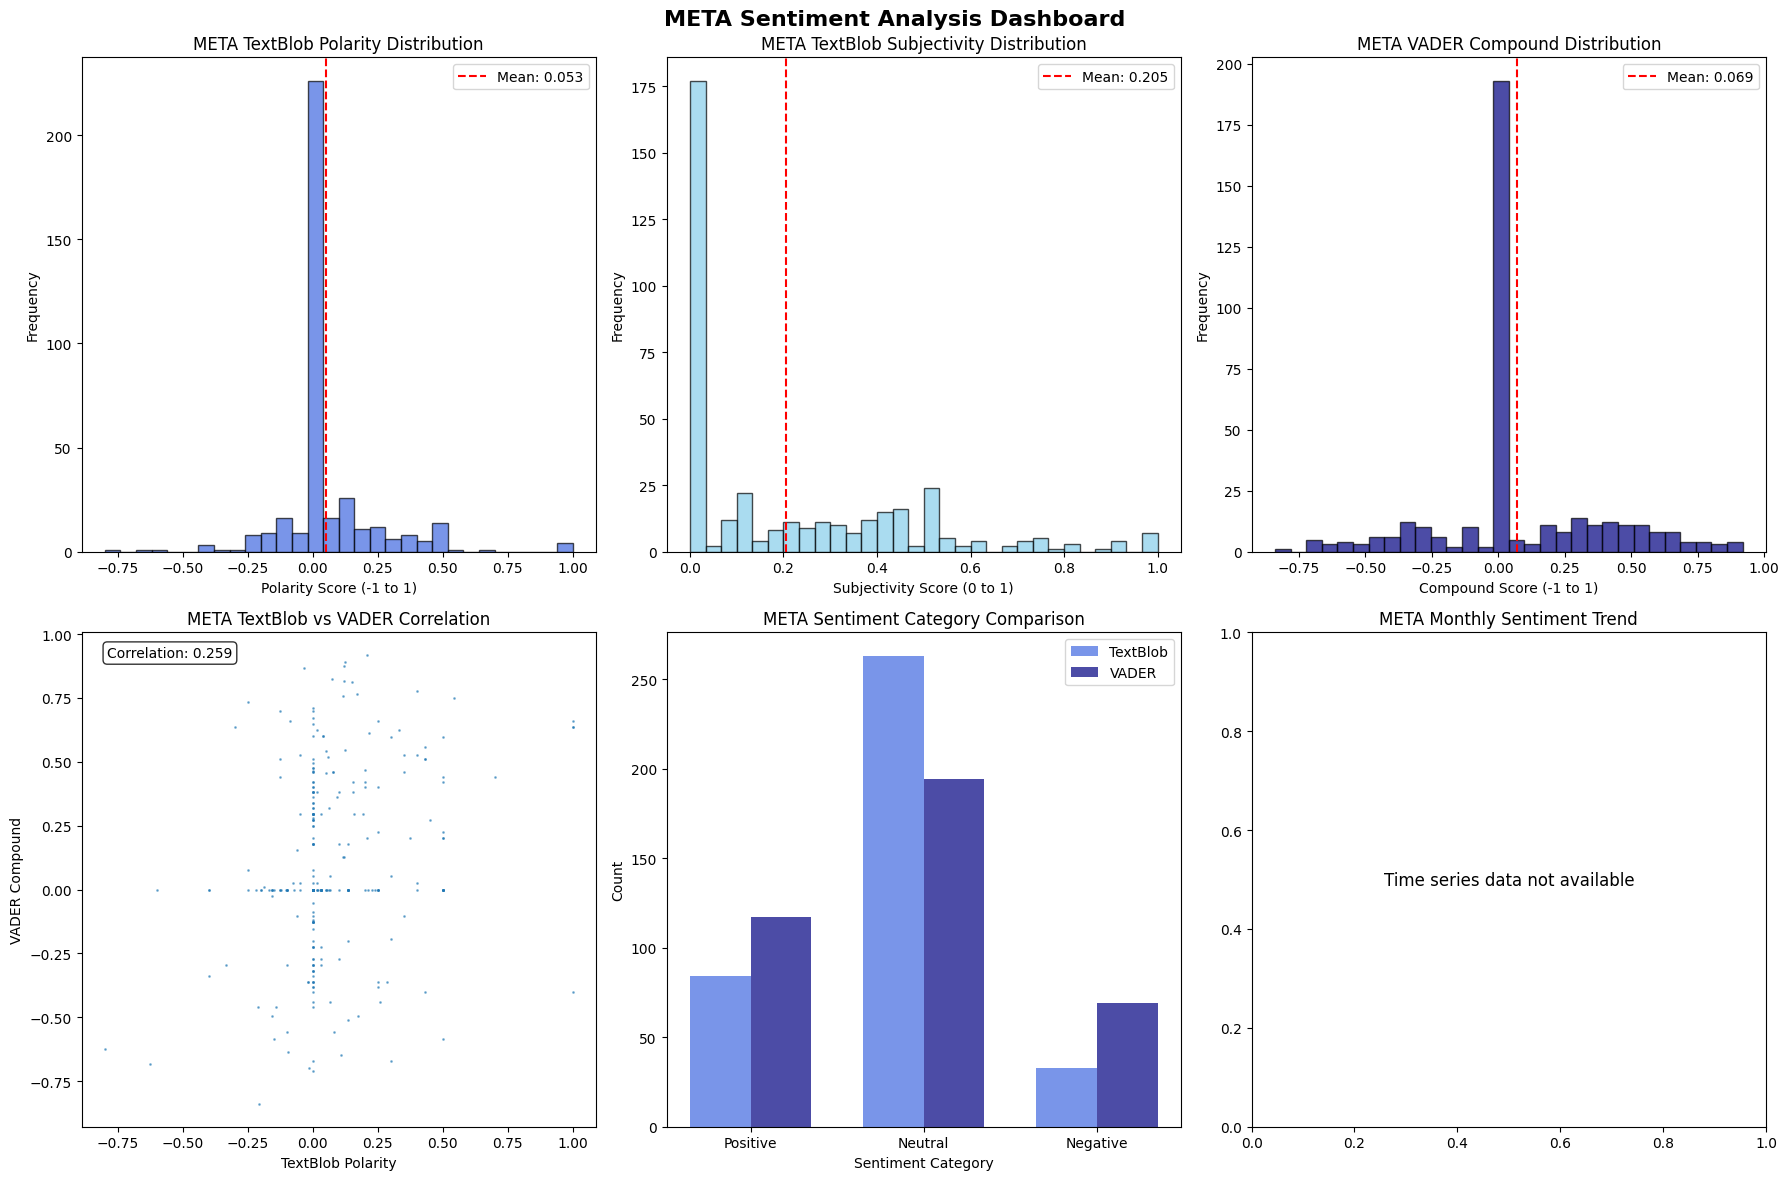

In [6]:
# Create META sentiment visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('META Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# TextBlob Polarity distribution
axes[0, 0].hist(meta_data['textblob_polarity'], bins=30, alpha=0.7, color='royalblue', edgecolor='black')
axes[0, 0].set_title('META TextBlob Polarity Distribution')
axes[0, 0].set_xlabel('Polarity Score (-1 to 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(meta_data['textblob_polarity'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {meta_data["textblob_polarity"].mean():.3f}')
axes[0, 0].legend()

# TextBlob Subjectivity distribution
axes[0, 1].hist(meta_data['textblob_subjectivity'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_title('META TextBlob Subjectivity Distribution')
axes[0, 1].set_xlabel('Subjectivity Score (0 to 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(meta_data['textblob_subjectivity'].mean(), color='red', linestyle='--',
                   label=f'Mean: {meta_data["textblob_subjectivity"].mean():.3f}')
axes[0, 1].legend()

# VADER Compound distribution
axes[0, 2].hist(meta_data['vader_compound'], bins=30, alpha=0.7, color='navy', edgecolor='black')
axes[0, 2].set_title('META VADER Compound Distribution')
axes[0, 2].set_xlabel('Compound Score (-1 to 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(meta_data['vader_compound'].mean(), color='red', linestyle='--',
                   label=f'Mean: {meta_data["vader_compound"].mean():.3f}')
axes[0, 2].legend()

# Correlation scatter plot
axes[1, 0].scatter(meta_data['textblob_polarity'], meta_data['vader_compound'], alpha=0.5, s=1)
axes[1, 0].set_title('META TextBlob vs VADER Correlation')
axes[1, 0].set_xlabel('TextBlob Polarity')
axes[1, 0].set_ylabel('VADER Compound')
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sentiment categories
def categorize_sentiment(score, tool='textblob'):
    if tool == 'textblob':
        if score > 0.1:
            return 'Positive'
        elif score < -0.1:
            return 'Negative'
        else:
            return 'Neutral'
    else:  # VADER
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

meta_data['textblob_category'] = meta_data['textblob_polarity'].apply(lambda x: categorize_sentiment(x, 'textblob'))
meta_data['vader_category'] = meta_data['vader_compound'].apply(lambda x: categorize_sentiment(x, 'vader'))

# Category comparison
categories = ['Positive', 'Neutral', 'Negative']
tb_counts = [meta_data['textblob_category'].value_counts().get(cat, 0) for cat in categories]
vader_counts = [meta_data['vader_category'].value_counts().get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, tb_counts, width, label='TextBlob', color='royalblue', alpha=0.7)
axes[1, 1].bar(x + width/2, vader_counts, width, label='VADER', color='navy', alpha=0.7)
axes[1, 1].set_title('META Sentiment Category Comparison')
axes[1, 1].set_xlabel('Sentiment Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()

# Time series of sentiment (if dates are available)
try:
    meta_data['date_clean'] = pd.to_datetime(meta_data['date'], errors='coerce')
    meta_time = meta_data.dropna(subset=['date_clean']).copy()
    meta_time = meta_time.sort_values('date_clean')
    
    # Resample by month for smoother trend
    meta_time.set_index('date_clean', inplace=True)
    monthly_sentiment = meta_time['textblob_polarity'].resample('M').mean()
    
    axes[1, 2].plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', linewidth=2, color='royalblue')
    axes[1, 2].set_title('META Monthly Sentiment Trend')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Average Polarity')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
except:
    axes[1, 2].text(0.5, 0.5, 'Time series data not available', ha='center', va='center',
                   transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('META Monthly Sentiment Trend')

plt.tight_layout()
plt.show()

In [7]:
# Show extreme sentiment examples for META
print("=== META EXTREME SENTIMENT EXAMPLES ===")

# Most positive headlines (TextBlob)
most_positive_tb = meta_data.nlargest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Positive META Headlines (TextBlob):")
for idx, row in most_positive_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (TextBlob)
most_negative_tb = meta_data.nsmallest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Negative META Headlines (TextBlob):")
for idx, row in most_negative_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most positive headlines (VADER)
most_positive_vader = meta_data.nlargest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Positive META Headlines (VADER):")
for idx, row in most_positive_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (VADER)
most_negative_vader = meta_data.nsmallest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Negative META Headlines (VADER):")
for idx, row in most_negative_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

=== META EXTREME SENTIMENT EXAMPLES ===

Most Positive META Headlines (TextBlob):
   1.000: Munster Says Still 'Neutral' On Facebook's Long-Term Outlook Despite Impressive ...
   1.000: Wedbush Maintains Outperform on Facebook, Maintains $250 Price Target; Adds To B...
   1.000: Hearing Wedbush Added Amazon, Peloton And Facebook To Best Ideas List; Unconfirm...
   1.000: Best Home Office Essentials During The COVID-19 (Coronavirus) Lockdown...
   0.700: For Some Companies, A Sliver Of Good News During COVID-19...

Most Negative META Headlines (TextBlob):
   -0.800: Facebook Removed 9.6M Posts For Hate Speech In Q1, Warns Of Coronavirus Impact O...
   -0.625: Trump Gets Mad Over Fact Check Warning On Twitter, Claims Election Interference...
   -0.600: 7 Times Elon Musk Wasn't Afraid To Speak His Mind...
   -0.400: Facebook Posts Blog Post Titled 'Verifying the Identity of People Behind High-Re...
   -0.400: The Secret to Tech's Resilience to COVID-19- Infrastructure Expansion...

Most P

In [8]:
# Save META results
print("=== SAVING META RESULTS ===")

# Create output dataframe
meta_output = meta_data[['headline', 'publisher', 'date', 'stock', 
                       'textblob_polarity', 'textblob_subjectivity', 'textblob_category',
                       'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']].copy()

# Save to CSV
output_file = '../../../data/sentiment_analysis_META.csv'
meta_output.to_csv(output_file, index=False)
print(f"META results saved to: {output_file}")
print(f"Total META headlines processed: {len(meta_output)}")

# Display final summary
print("\n=== META FINAL SUMMARY ===")
print(f"Dataset: {len(meta_data):,} META headlines")
print(f"Date range: {pd.to_datetime(meta_data['date'], errors='coerce').min()} to {pd.to_datetime(meta_data['date'], errors='coerce').max()}")
print(f"Unique publishers: {meta_data['publisher'].nunique()}")
print(f"TextBlob - Mean polarity: {meta_data['textblob_polarity'].mean():.4f}")
print(f"VADER - Mean compound: {meta_data['vader_compound'].mean():.4f}")

agreement = (meta_data['textblob_category'] == meta_data['vader_category']).mean()
print(f"Tool agreement: {agreement:.2%}")

print("\n=== META SENTIMENT CATEGORY DISTRIBUTIONS ===")
print("\nTextBlob Categories:")
print(meta_data['textblob_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nVADER Categories:")
print(meta_data['vader_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== SAVING META RESULTS ===
META results saved to: ../../../data/sentiment_analysis_META.csv
Total META headlines processed: 380

=== META FINAL SUMMARY ===
Dataset: 380 META headlines
Date range: 2020-06-08 05:54:23-04:00 to 2020-06-10 16:20:19-04:00
Unique publishers: 38
TextBlob - Mean polarity: 0.0527
VADER - Mean compound: 0.0690
Tool agreement: 54.47%

=== META SENTIMENT CATEGORY DISTRIBUTIONS ===

TextBlob Categories:
textblob_category
Neutral     69.21%
Positive    22.11%
Negative     8.68%
Name: proportion, dtype: str

VADER Categories:
vader_category
Neutral     51.05%
Positive    30.79%
Negative    18.16%
Name: proportion, dtype: str


## META Sentiment Analysis Summary

### Key Findings:
- **Overall Sentiment**: [Based on mean polarity/compound scores]
- **Sentiment Distribution**: [Analysis of positive/negative/neutral breakdown]
- **Subjectivity Level**: [Analysis of how objective vs subjective META news is]
- **Tool Agreement**: [How well TextBlob and VADER agree on META sentiment]

### Insights:
- META is social media giant, sentiment reflects digital advertising and social platform health
- High news volume indicates strong investor interest in social media and metaverse developments
- Sentiment patterns may correlate with user growth, ad revenue, and metaverse investments

### Recommendations:
- Monitor META sentiment as a social media and digital advertising indicator
- Use sentiment trends to anticipate metaverse development impacts and privacy concerns
- Compare META sentiment with other tech giants for relative strength analysis